In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
raw_shark_df = pd.read_csv("../data/clean_data/clean_data.csv")
shark_df = raw_shark_df.drop(["type", "country", "state"], axis=1)

print(shark_df.head(), "\n")

nonfatal_df = shark_df[shark_df["fatal"] == "N"]
fatal_df = shark_df[shark_df["fatal"] == "Y"]

# compute overall statistics
total_attacks = len(shark_df)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

   activity  sex   age fatal       time      species  year  month
0  swimming    m  12.0     N  afternoon          NaN   NaN    6.0
1  swimming    f  17.0     N    morning          NaN   NaN    6.0
2  swimming    f  35.0     N    morning  great white   NaN    6.0
3  swimming    f   NaN     N  afternoon          NaN   NaN    6.0
4  swimming  NaN   NaN     N    morning         bull   NaN    6.0 

Total number of attacks: 5164
Number of fatal attacks: 1273
Number of nonfatal attacks: 3891
Overall fatality rate: 24.65%


## Activity Analysis

In [7]:
activity_counts = fatal_df.groupby("activity").size().to_frame(name="fatal_count").reset_index()
activity_counts["nonfatal_count"] = nonfatal_df.groupby("activity").size().to_list()
activity_counts["total_count"] = activity_counts["fatal_count"] + activity_counts["nonfatal_count"]
activity_counts["fatality_rate"] = activity_counts["fatal_count"] / activity_counts["total_count"]
activity_counts["perc_of_total"] = activity_counts["total_count"] / total_attacks

# drop activities that account for less than 1% of attacks
activity_counts = activity_counts[activity_counts["perc_of_total"] >= 0.01]
activity_counts.drop(["perc_of_total"], axis=1, inplace=True)

# drop adrift due to uncertainty of circumstances
activity_counts = activity_counts[activity_counts["activity"] != "adrift"]

# sort for visuals
activity_counts.sort_values("total_count", ascending=True, inplace=True)

activity_counts

,activity,fatal_count,nonfatal_count,total_count,fatality_rate
6,small watercraft,14,71,85,0.164706
4,fishing,74,188,262,0.282443
2,dive fishing,71,326,397,0.178841
3,diving,135,325,460,0.293478
9,wading,153,464,617,0.247974
8,swimming,437,870,1307,0.334353
7,surfing/bodyboarding,108,1254,1362,0.079295


In [9]:
def fatality_rate_plots(fatal_counts_df, attribute_name: str, max_x=1400, legend_pos="lower right"):

    fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
    axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.5)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(f"Shark Attacks by {title_word}", fontsize=16)

    plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

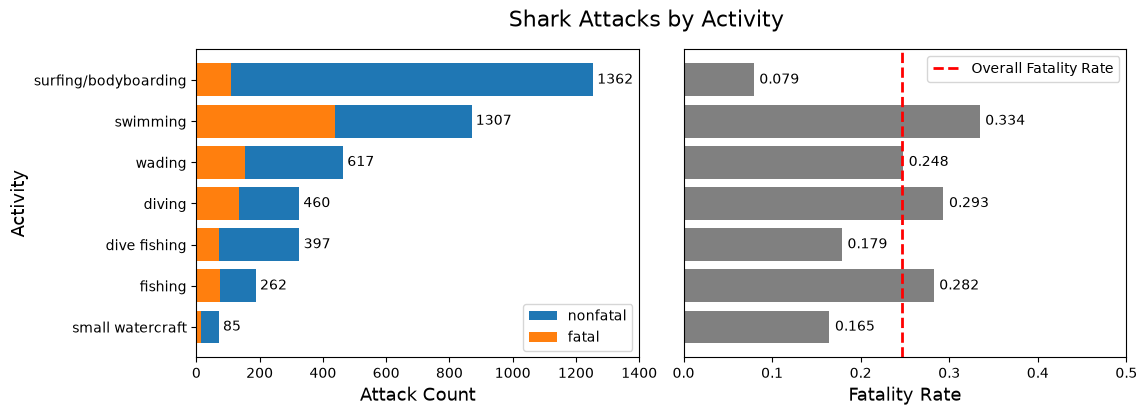

In [10]:
fatality_rate_plots(activity_counts, "activity")

## Time of Day Analysis

In [12]:
time_counts = fatal_df.groupby("time").size().to_frame(name="fatal_count").reset_index()
time_counts["nonfatal_count"] = nonfatal_df.groupby("time").size().to_list()
time_counts["total_count"] = time_counts["fatal_count"] + time_counts["nonfatal_count"]
time_counts["fatality_rate"] = time_counts["fatal_count"] / time_counts["total_count"]
time_counts["perc_of_total"] = time_counts["total_count"] / total_attacks

# drop 
# time_counts = time_counts[time_counts["perc_of_total"] >= 0.01]
# time_counts.drop(["perc_of_total"], axis=1, inplace=True)

# sort for visuals
time_counts.sort_values("total_count", ascending=True, inplace=True)

time_counts

,time,fatal_count,nonfatal_count,total_count,fatality_rate,perc_of_total
3,night,20,46,66,0.303030,0.012781
1,evening,78,401,479,0.162839,0.092758
2,morning,175,807,982,0.178208,0.190163
0,afternoon,254,1145,1399,0.181558,0.270914


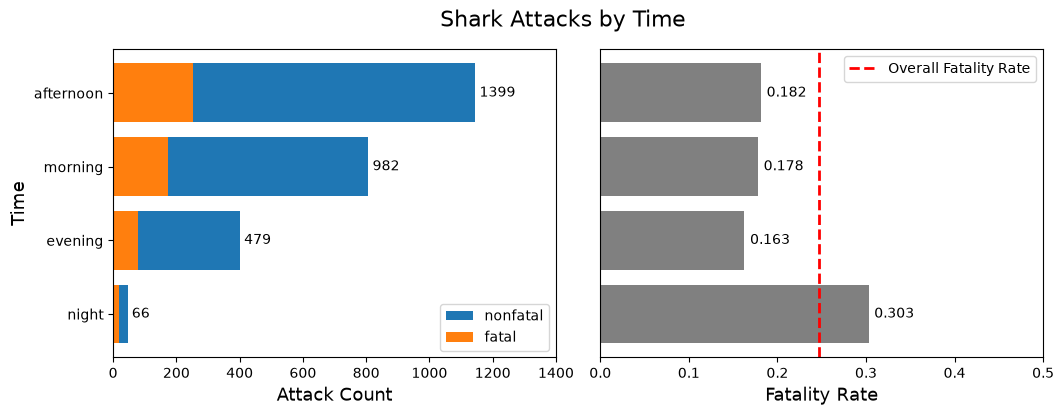

In [13]:
fatality_rate_plots(time_counts, "time")

## Species Analysis

In [14]:
species_counts1 = fatal_df.groupby("species").size().to_frame(name="fatal_count").reset_index()
species_counts2 = nonfatal_df.groupby("species").size().to_frame(name="nonfatal_count").reset_index()
species_counts = pd.merge(species_counts2, species_counts1, on="species", how="left").fillna(0)
species_counts["total_count"] = species_counts["fatal_count"] + species_counts["nonfatal_count"]
species_counts["fatality_rate"] = species_counts["fatal_count"] / species_counts["total_count"]
species_counts["perc_of_total"] = species_counts["total_count"] / species_counts["total_count"].sum()

# drop those that account for less than 2% of attacks with species listed
species_counts = species_counts[species_counts["perc_of_total"] >= 0.02]
species_counts.drop(["perc_of_total"], axis=1, inplace=True)

# sort for visuals
species_counts.sort_values("total_count", ascending=True, inplace=True)

species_counts

,species,nonfatal_count,fatal_count,total_count,fatality_rate
17,wobbegong,43,0.0,43.0,0.000000
10,nurse,46,1.0,47.0,0.021277
14,spinner,53,0.0,53.0,0.000000
2,bronze whaler,62,6.0,68.0,0.088235
0,blacktip,72,2.0,74.0,0.027027
12,reef,75,0.0,75.0,0.000000
3,bull,198,51.0,249.0,0.204819
15,tiger,209,79.0,288.0,0.274306
6,great white,383,162.0,545.0,0.297248


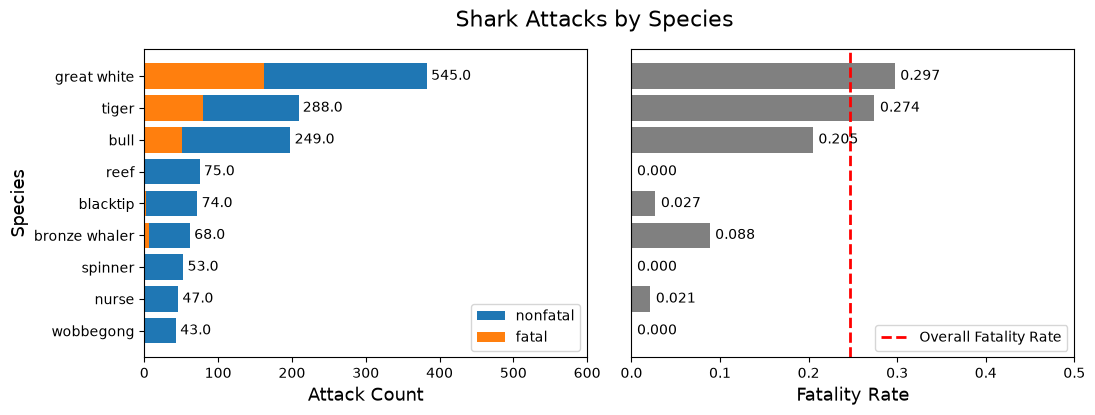

In [15]:
fatality_rate_plots(species_counts, "species", max_x=600)